In [1]:
import spatialdata as sd 
import spatialdata_io as sio
from napari_spatialdata import Interactive
import squidpy as sq
from shapely.geometry import Polygon, Point

from spatialdata.transformations import (
    align_elements_using_landmarks,
    get_transformation_between_landmarks,
)

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
Xenium = sd.read_zarr('Version 2 Zarr//Sample_1D_annotated.zarr', selection=["tables"])

c:\Users\laure\anaconda3\envs\cluster_var\lib\site-packages\spatialdata\_core\spatialdata.py:155: UserWarning: The table is annotating 'cell_circles', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


In [5]:
Xenium

SpatialData object with:
└── Tables
      └── 'table': AnnData (9829, 345)
with coordinate systems:

In [3]:
Interactive(Xenium)

2024-06-14 10:44:00.887 | INFO     | napari_spatialdata._viewer:add_sdata_points:529 - Subsampling points because the number of points exceeds the currently supported 100 000.


In [12]:
Xenium.tables["table"]

AnnData object with n_obs × n_vars = 6342 × 345
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'cell_labels', 'plaque_region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'plaque_region_colors', 'spatialdata_attrs'
    obsm: 'spatial'

In [9]:
del Xenium.shapes["Necrotic_core"]

In [5]:
cell_coords = Xenium.tables["table"].obsm["spatial"]
Intima = Xenium.shapes["Intima"].iloc[0, 0]
Media = Xenium.shapes["Media"].iloc[0, 0]
Thrombus = Xenium.shapes["Thrombus"].iloc[0, 0]
Fibrous_cap = Xenium.shapes["Fibrous_cap"].iloc[0, 0]
Necrotic_core = Xenium.shapes["Necrotic_core"].iloc[0, 0]
#Intima_2 = Xenium.shapes["Intima_2"].iloc[0, 0]

In [6]:
def get_region(point, Thrombus, Fibrous_cap, Necrotic_core, Intima, Media):
    point = Point(point)
    if Thrombus.contains(point):
        return "Thrombus"
    elif Fibrous_cap.contains(point) and not Thrombus.contains(point):
       return "Fibrous_cap"
    elif Necrotic_core.contains(point) and not Fibrous_cap.contains(point) and not Thrombus.contains(point):
         return "Necrotic_core"
    elif Intima.contains(point) and not Necrotic_core.contains(point) and not Fibrous_cap.contains(point) and not Thrombus.contains(point):
        return "Intima"
    elif Media.contains(point) and not Intima.contains(point) and not Necrotic_core.contains(point) and not Fibrous_cap.contains(point) and not Thrombus.contains(point):
        return "Media"
#    elif polygon5.contains(point):
#       return "Necrotic_core"
#    elif polygon5.contains(point):
#       return "Intima"
    else:
        return "None"

In [7]:
Xenium.tables["table"].obs['plaque_region'] = [get_region(coord, Thrombus, Fibrous_cap, Necrotic_core, Intima, Media) for coord in cell_coords]
Xenium.tables["table"].obs['plaque_region'] = Xenium.tables["table"].obs['plaque_region'].astype('category')

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


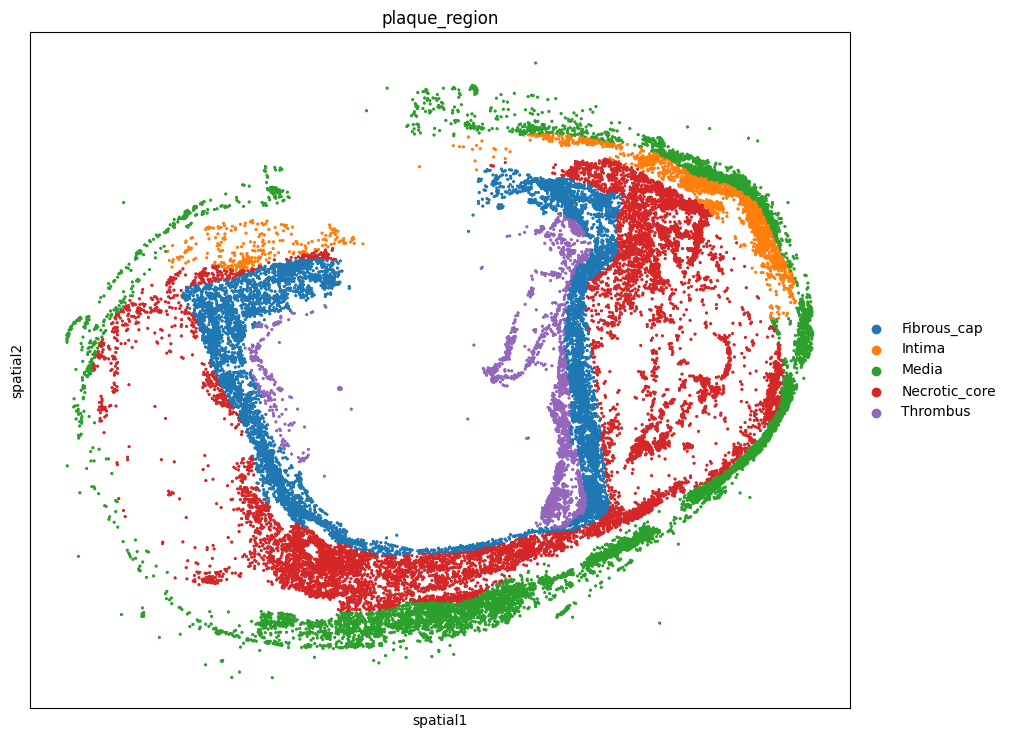

In [16]:
sq.pl.spatial_scatter(
    Xenium.tables["table"], color=["plaque_region"], shape=None, figsize=(10, 10)
)

In [12]:
def find_closest_region(point, polygon1, polygon2, polygon3, polygon4=None, polygon5=None):
    point = Point(point)
    dist_to_region1 = point.distance(polygon1)
    dist_to_region2 = point.distance(polygon2)
    dist_to_region3 = point.distance(polygon3)
    dist_to_region4 = point.distance(polygon4)
    dist_to_region5 = point.distance(polygon5)
    distance_to_region_list = [(dist_to_region1, "Intima"), (dist_to_region2, "Media"), (dist_to_region3, "Thrombus"), (dist_to_region4, "Fibrous_cap"), (dist_to_region5, "Necrotic_core")]
    smallest_distance, closest_polygon = min(distance_to_region_list, key=lambda x: x[0])
    return closest_polygon

In [13]:
for i, row in Xenium.tables["table"].obs.iterrows():
    if row['plaque_region'] == 'None':
        Xenium.tables["table"].obs.at[i, 'plaque_region'] = find_closest_region(cell_coords[int(i)], Intima, Media, Thrombus, Fibrous_cap, Necrotic_core)

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


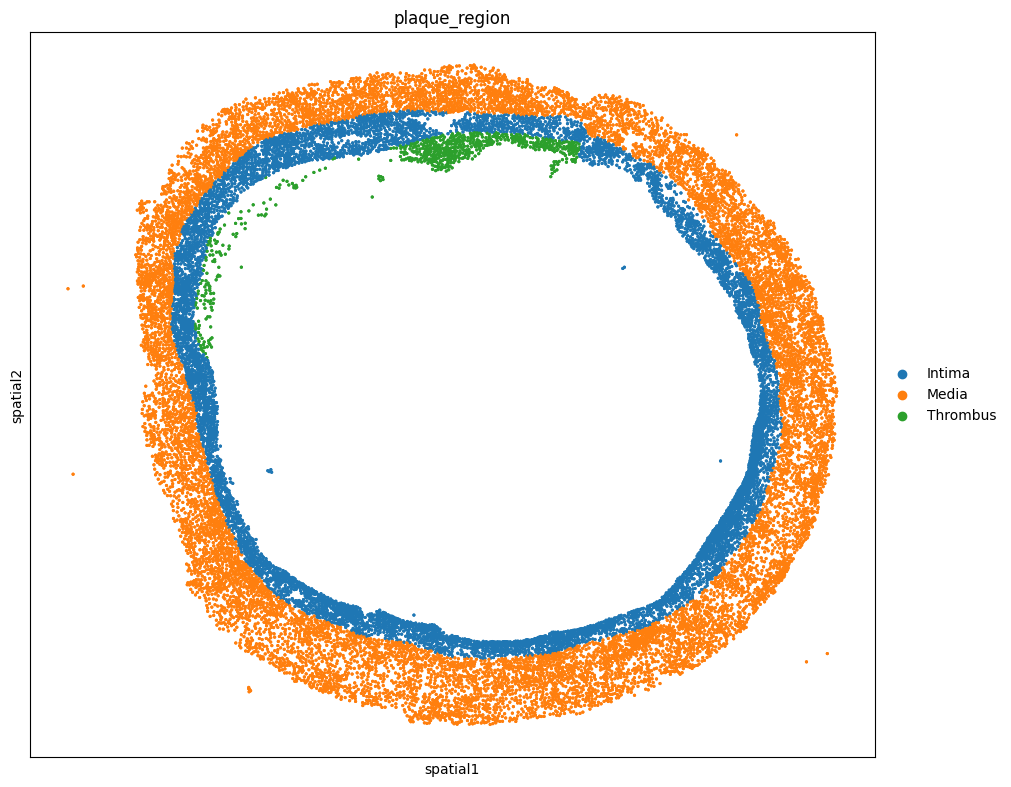

In [13]:
sq.pl.spatial_scatter(
    Xenium.tables["table"], color=["plaque_region"], shape=None, figsize=(10, 10)
)

In [15]:
Xenium.tables["table"].obs["plaque_region"] = Xenium.tables["table"].obs["plaque_region"].cat.remove_categories(['None'])

In [16]:
del Xenium.tables["table"].uns['plaque_region_colors']

In [17]:
Xenium.tables["table"].obs["plaque_region"].unique()

['Media', 'Intima', 'Thrombus']
Categories (3, object): ['Intima', 'Media', 'Thrombus']

C:\Users\laure\Desktop\github\spatial_de\squidpy\src\squidpy\pl\_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


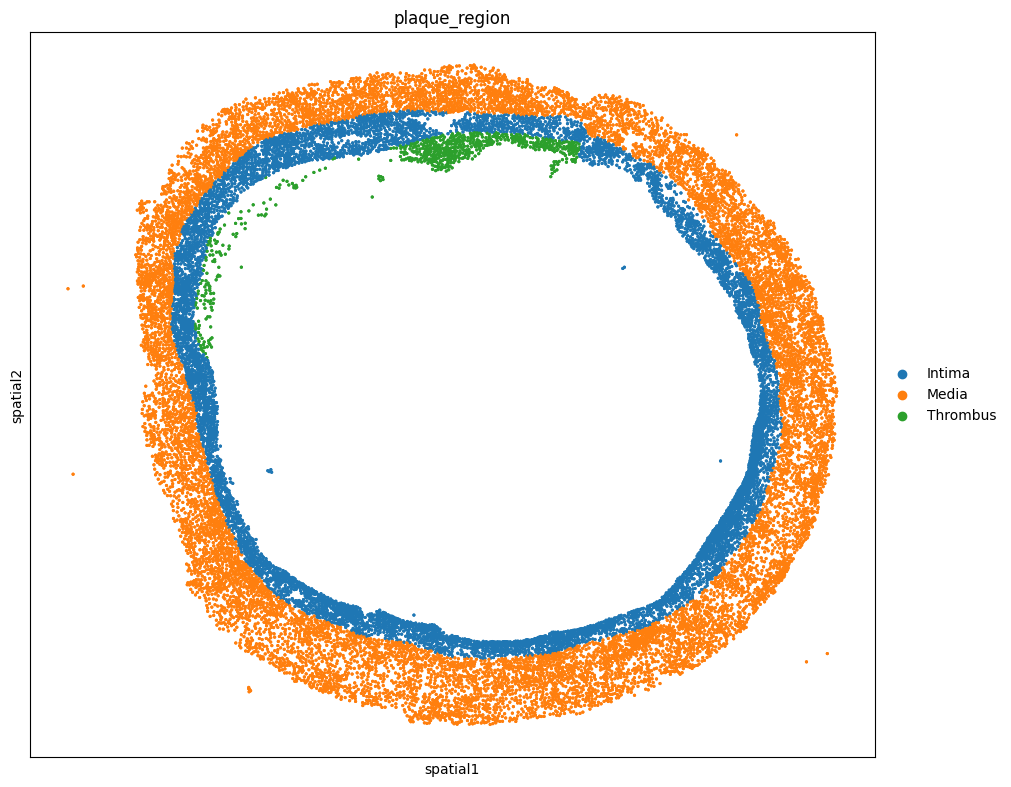

In [18]:
sq.pl.spatial_scatter(
    Xenium.tables["table"], color=["plaque_region"], shape=None, figsize=(10, 10)
)

In [9]:
Xenium.write('Version 2 Zarr//Sample_4D_annotated.zarr', overwrite=True)

INFO     The Zarr file used for backing will now change from Version 2 Zarr\Sample 4D.zarr to Version 2            
         Zarr\Sample_4D_annotated.zarr                                                                             


In [4]:
affine = get_transformation_between_landmarks(
    references_coords=Xenium["Xenium_landmarks"], moving_coords=Xenium["HE_landmarks"]
)
affine

Affine (x, y -> x, y)
    [  -7.68342807   52.71443347 2596.80595917]
    [-5.27144335e+01 -7.68342807e+00  2.55473215e+04]
    [0. 0. 1.]

In [5]:
affine = align_elements_using_landmarks(
    references_coords=Xenium["Xenium_landmarks"],
    moving_coords=Xenium["HE_landmarks"],
    reference_element=Xenium["transcripts"],
    moving_element=Xenium["1.4H.tiff"],
    reference_coordinate_system="global",
    moving_coordinate_system="global",
    new_coordinate_system="aligned",
)
affine

Sequence 
    Identity 
    Affine (x, y -> x, y)
        [  -7.68342807   52.71443347 2596.80595917]
        [-5.27144335e+01 -7.68342807e+00  2.55473215e+04]
        [0. 0. 1.]

In [6]:
Interactive(Xenium)

2024-06-14 10:09:38.552 | INFO     | napari_spatialdata._viewer:add_sdata_points:529 - Subsampling points because the number of points exceeds the currently supported 100 000.
